# Classification with PyTorch (oracle) — Response

**Role:** reference oracle used purely to check the from-scratch twin behaves correctly. Same data, same features, same architecture, same seed.

**EDA recap (slide_deck.html):** target `Response` (14.9% positive / 85.1% negative, n=2,237 after cleaning). Features = 3/3 consensus (10) + 2/3 (8) = 18 columns listed in the Load-Data cell. `Marital_Status` is the only categorical → one-hot (5 dummies) → model input dim = 22.

Pipeline: Load Data → Dataset Class → DataLoader → Model Class → Training Loop → Inference Loop. Weights saved to `./weights/classification_mlp.pt`.

In [1]:
import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
os.makedirs("weights", exist_ok=True)
print("torch:", torch.__version__)

# ---- 1. LOAD DATA ----
df = pd.read_csv("marketing_campaign.csv", sep="\t")
print("raw:", df.shape)

# Cleaning (identical to classify.ipynb / slide_deck §05)
df = df.drop(columns=["ID", "Z_CostContact", "Z_Revenue"])
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], format="%d-%m-%Y")
ref_date = df["Dt_Customer"].max()
df["Customer_Tenure_Days"] = (ref_date - df["Dt_Customer"]).dt.days
df["Age"] = 2014 - df["Year_Birth"]
df = df[~df["Year_Birth"].isin([1893, 1899, 1900])].copy()  # 3 age outliers
df["Marital_Status"] = df["Marital_Status"].replace({"Absurd": "Single", "YOLO": "Single", "Alone": "Single"})
print("cleaned:", df.shape, "| Response rate:", round(df["Response"].mean(), 4))

# EDA 3/3 (10) + 2/3 (8) feature set
CLF_NUMERIC = [
    "AcceptedCmp5", "AcceptedCmp3", "MntWines", "MntMeatProducts",
    "NumCatalogPurchases", "Recency", "Customer_Tenure_Days", "MntGoldProds",
    "Income", "MntFruits",  # 3/3
    "AcceptedCmp1", "AcceptedCmp2", "NumWebPurchases", "MntSweetProducts",
    "MntFishProducts", "NumStorePurchases", "Age",  # 2/3 numeric
]
X_num = df[CLF_NUMERIC].copy()
X_cat = pd.get_dummies(df[["Marital_Status"]], dtype=float)
X_full = pd.concat([X_num, X_cat], axis=1)
DUMMY_COLS = list(X_cat.columns)
FEATURE_COLS = list(X_full.columns)
y_full = df["Response"].astype(float).values
print(f"features: {len(CLF_NUMERIC)} numeric + {len(DUMMY_COLS)} dummies = {len(FEATURE_COLS)} dims")
print("dummies:", DUMMY_COLS)

torch: 2.14.1
raw: (2240, 29)
cleaned: (2237, 28) | Response rate: 0.1493
features: 17 numeric + 5 dummies = 22 dims
dummies: ['Marital_Status_Divorced', 'Marital_Status_Married', 'Marital_Status_Single', 'Marital_Status_Together', 'Marital_Status_Widow']


## 2–3. Dataset Class + DataLoader (80/20 stratified, StandardScaler train-fit-only)

In [2]:
class TabularDataset(Dataset):
    """Minimal torch Dataset: returns (x float32, y float32 shape (1,))."""
    def __init__(self, X, y):
        self.X = torch.from_numpy(np.asarray(X, dtype=np.float32))
        self.y = torch.from_numpy(np.asarray(y, dtype=np.float32)).view(-1, 1)
    def __len__(self):
        return self.X.shape[0]
    def __getitem__(self, i):
        return self.X[i], self.y[i]

X_temp, X_test, y_temp, y_test = train_test_split(
    X_full.values, y_full, test_size=0.20, random_state=SEED, stratify=y_full)
# Income has 24 NaNs: median-fill using TRAIN median only (no leakage)
inc_idx = FEATURE_COLS.index("Income")
train_median = np.nanmedian(X_temp[:, inc_idx])
for arr in (X_temp, X_test):
    arr[:, inc_idx] = np.where(np.isnan(arr[:, inc_idx]), train_median, arr[:, inc_idx])
print(f"train median Income fill: {train_median:.0f}")

scaler = StandardScaler().fit(X_temp)
Xtr, Xte = scaler.transform(X_temp), scaler.transform(X_test)
print(f"train {Xtr.shape} test {Xte.shape} | test pos rate {y_test.mean():.3f}")

train_ds, test_ds = TabularDataset(Xtr, y_temp), TabularDataset(Xte, y_test)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True,
                            generator=torch.Generator().manual_seed(SEED))
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False)
print(f"batches: {len(train_loader)} train / {len(test_loader)} test")

train median Income fill: 51533
train (1789, 22) test (448, 22) | test pos rate 0.150
batches: 28 train / 2 test


## 4. Model Class — shared spec: Linear(22→32) → ReLU → Linear(32→1), He init, no dropout

In [3]:
class ClfMLP(nn.Module):
    def __init__(self, in_dim=22, h=32):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, h)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(h, 1)
        nn.init.kaiming_normal_(self.fc1.weight, nonlinearity="relu")  # He init
        nn.init.zeros_(self.fc1.bias)
        nn.init.kaiming_normal_(self.fc2.weight, nonlinearity="linear")
        nn.init.zeros_(self.fc2.bias)
    def forward(self, x):
        return self.fc2(self.relu(self.fc1(x)))  # logits

device = torch.device("cpu")  # forced cpu so NumPy twin matches exactly
model = ClfMLP(in_dim=len(FEATURE_COLS)).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"params: {n_params} (expect 22*32+32 + 32*1+1 = 769)")

pos = (y_temp == 1).sum(); neg = (y_temp == 0).sum()
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([neg / pos]))
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, betas=(0.9, 0.999), eps=1e-8)
print(f"pos_weight (neg/pos): {neg / pos:.3f}")

ClfMLP(
  (fc1): Linear(in_features=22, out_features=32, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=32, out_features=1, bias=True)
)
params: 769 (expect 22*32+32 + 32*1+1 = 769)


pos_weight (neg/pos): 5.700


## 5. Training Loop (50 epochs, Adam) — logs train/val loss + val F1, saves weights

epoch 01 | train_loss 1.2106 | val_loss 0.6052 | val_acc 0.7098 | val_f1 0.3689


epoch 10 | train_loss 0.7225 | val_loss 0.4367 | val_acc 0.7991 | val_f1 0.5312


epoch 20 | train_loss 0.6313 | val_loss 0.4102 | val_acc 0.7857 | val_f1 0.5000


epoch 30 | train_loss 0.5916 | val_loss 0.4025 | val_acc 0.7969 | val_f1 0.5081


epoch 40 | train_loss 0.5636 | val_loss 0.4025 | val_acc 0.8013 | val_f1 0.5189


epoch 50 | train_loss 0.5386 | val_loss 0.3903 | val_acc 0.8036 | val_f1 0.5165
saved: weights/classification_mlp.pt + scaler.npz + pytorch_history.csv


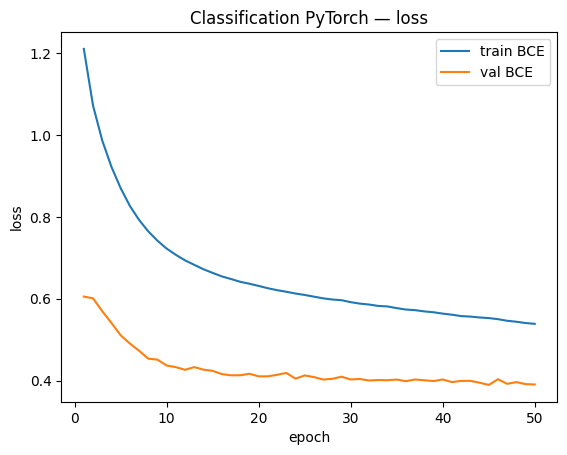

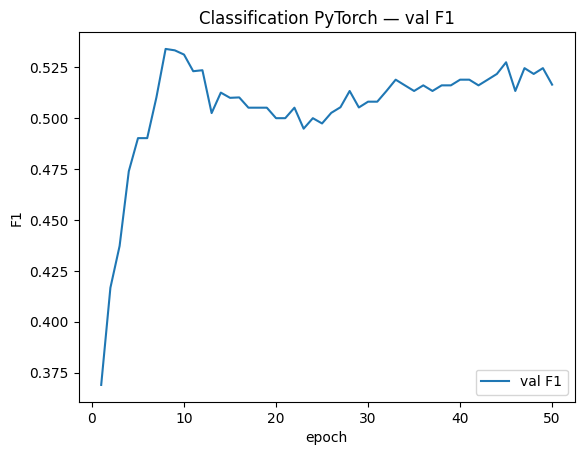

In [4]:
EPOCHS = 50
history = {"epoch": [], "train_loss": [], "val_loss": [], "val_acc": [], "val_f1": []}
bce = nn.BCEWithLogitsLoss()

def evaluate(m):
    m.eval()
    with torch.no_grad():
        Xt = torch.from_numpy(Xte.astype(np.float32)).to(device)
        yt = torch.from_numpy(y_test.astype(np.float32)).view(-1, 1).to(device)
        logits = m(Xt)
        loss = bce(logits, yt).item()
        prob = torch.sigmoid(logits).cpu().numpy().ravel()
        pred = (prob >= 0.5).astype(int)
        return loss, accuracy_score(y_test, pred), f1_score(y_test, pred)

for epoch in range(1, EPOCHS + 1):
    model.train()
    tot, n = 0.0, 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        tot += loss.item() * len(xb); n += len(xb)
    vl, va, vf = evaluate(model)
    history["epoch"].append(epoch)
    history["train_loss"].append(tot / n)
    history["val_loss"].append(vl)
    history["val_acc"].append(va)
    history["val_f1"].append(vf)
    if epoch == 1 or epoch % 10 == 0 or epoch == EPOCHS:
        print(f"epoch {epoch:02d} | train_loss {tot/n:.4f} | val_loss {vl:.4f} | val_acc {va:.4f} | val_f1 {vf:.4f}")

torch.save(model.state_dict(), "weights/classification_mlp.pt")
np.savez("weights/classification_scaler.npz", mean=scaler.mean_, scale=scaler.scale_,
         columns=np.array(FEATURE_COLS), train_median=np.array([train_median]))
pd.DataFrame(history).to_csv("weights/classification_pytorch_history.csv", index=False)
print("saved: weights/classification_mlp.pt + scaler.npz + pytorch_history.csv")

plt.figure(); plt.plot(history["epoch"], history["train_loss"], label="train BCE")
plt.plot(history["epoch"], history["val_loss"], label="val BCE")
plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend(); plt.title("Classification PyTorch — loss"); plt.show()
plt.figure(); plt.plot(history["epoch"], history["val_f1"], label="val F1")
plt.xlabel("epoch"); plt.ylabel("F1"); plt.legend(); plt.title("Classification PyTorch — val F1"); plt.show()

## 6. Inference Loop — fresh instance loads `./weights/classification_mlp.pt`

In [5]:
fresh = ClfMLP(in_dim=len(FEATURE_COLS)).to(device)
fresh.load_state_dict(torch.load("weights/classification_mlp.pt", map_location=device))
fresh.eval()
with torch.no_grad():
    Xt = torch.from_numpy(Xte.astype(np.float32)).to(device)
    prob = torch.sigmoid(fresh(Xt)).cpu().numpy().ravel()
pred = (prob >= 0.5).astype(int)
test_bce = float(bce(fresh(Xt), torch.from_numpy(y_test.astype(np.float32)).view(-1,1).to(device)).item())
metrics = {
    "test_loss_BCE": round(test_bce, 4),
    "accuracy": round(float(accuracy_score(y_test, pred)), 4),
    "precision": round(float(precision_score(y_test, pred, zero_division=0)), 4),
    "recall": round(float(recall_score(y_test, pred, zero_division=0)), 4),
    "f1": round(float(f1_score(y_test, pred, zero_division=0)), 4),
    "roc_auc": round(float(roc_auc_score(y_test, prob)), 4),
    "n_test": int(len(y_test)), "seed": SEED,
}
print(json.dumps(metrics, indent=2))
with open("weights/classification_pytorch_test_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)
print("\nsample predictions (prob vs true):")
for i in range(5):
    print(f"  prob={prob[i]:.3f} pred={pred[i]} true={int(y_test[i])}")

{
  "test_loss_BCE": 0.3903,
  "accuracy": 0.8036,
  "precision": 0.4087,
  "recall": 0.7015,
  "f1": 0.5165,
  "roc_auc": 0.8725,
  "n_test": 448,
  "seed": 42
}

sample predictions (prob vs true):
  prob=0.050 pred=0 true=0
  prob=0.000 pred=0 true=0
  prob=0.014 pred=0 true=0
  prob=0.186 pred=0 true=0
  prob=0.034 pred=0 true=0
